# Часть 2: формирование переменных для модели

In [1]:
import pandas as pd

## 1. $ret_{rus}$

Цитата из статьи:

The aggregate U.S. real stock market return ( ret )
is obtained by subtracting the CPI inflation rate from the log returns on the CRSP valueweighted market portfolio

Значит берем stock market return и делим на ИПЦ

In [13]:
imoex = pd.read_csv("../russian_data/processed/imoex.csv")
imoex['date'] = pd.to_datetime(imoex['date'])

In [14]:
cpi = pd.read_csv("../russian_data/processed/cpi_rus.csv")
cpi['date'] = pd.to_datetime(cpi['date'])

In [15]:
net_t = imoex.sort_values('date')
cpi = cpi.sort_values('date')

In [16]:
import numpy as np

cpi['inflation'] = 100 * np.log(cpi['cpi_rus'] / cpi['cpi_rus'].shift(1))

In [17]:
ret_t = pd.merge(net_t, cpi[['date', 'inflation']], on='date', how='inner')

In [18]:
ret_t['log_return'] = np.log(ret_t['IMOEX'] / ret_t['IMOEX'].shift(1)) * 100
ret_t['ret_t'] = ret_t['log_return'] - ret_t['inflation']

In [19]:
ret_t = ret_t[['date', 'ret_t']]

In [21]:
ret_t = (
    ret_t.loc[ret_t["date"].between("2000-01-01", "2014-12-01")]
    .copy()
    .reset_index(drop=True)
)
ret_t["date"].min(), ret_t["date"].max(), len(ret_t)

(Timestamp('2000-01-01 00:00:00'), Timestamp('2014-12-01 00:00:00'), 180)

<Axes: xlabel='date', ylabel='ret_t'>

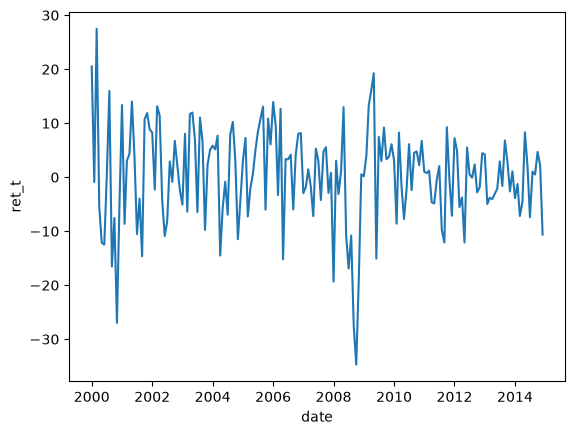

In [23]:
import seaborn as sns
sns.lineplot(x=ret_t['date'], y=ret_t['ret_t'])

Видна стационарность индекса, следовательно можем использовать как переменную в модели, но все же проверим ее через ADF тест позже

In [22]:
ret_t.to_csv("../russian_data/processed/ret_t.csv", index=False)

## 2. World oil production without Russia ($\Delta prod^{non-RUS}_t$)

Цитата из статьи: Our data include a measure of the percent change in world crude oil production

Значит берем ряды добычи нефти без РФ и считаем их в процентных изменениях

In [87]:
world_oil_prod = pd.read_csv("../original_data/processed/oil_prod_world.csv")
world_oil_prod['date'] = pd.to_datetime(world_oil_prod['date'])

In [88]:
russia_oil_prod = pd.read_csv("../russian_data/processed/oil_prod_russia.csv")
russia_oil_prod['date'] = pd.to_datetime(russia_oil_prod['date'])

In [89]:
world_oil_prod['delta_world'] = 100 * np.log(world_oil_prod['oil_prod_world'] / world_oil_prod['oil_prod_world'].shift(1))

In [90]:
world_oil_prod = pd.merge(world_oil_prod, russia_oil_prod, on='date', how='inner')

In [91]:
pd.infer_freq(world_oil_prod['date'])

'MS'

In [92]:
world_oil_prod

,date,oil_prod_world,delta_world,oil_prod_russia
0,1992-01-01,59751.576000,-1.769023,8191.0
1,1992-02-01,59615.598000,-0.227832,8164.0
2,1992-03-01,58495.335000,-1.897024,8110.0
3,1992-04-01,58332.507000,-0.278749,7994.0
4,1992-05-01,58119.599000,-0.365658,7900.0
...,...,...,...,...
271,2014-08-01,78491.319413,0.425677,10056.0
272,2014-09-01,79227.607413,0.933678,10079.0
273,2014-10-01,80212.039413,1.234880,10176.0
274,2014-11-01,79975.463413,-0.295374,10173.0


In [93]:
world_oil_prod['non_rus'] = world_oil_prod['oil_prod_world'] - world_oil_prod['oil_prod_russia']

In [94]:
world_oil_prod['delta_non_rus'] = 100 * np.log(world_oil_prod['non_rus'] / world_oil_prod['non_rus'].shift(1))


In [95]:
world_oil_prod = (
    world_oil_prod.loc[world_oil_prod["date"].between("2000-01-01", "2014-12-01")]
    .copy()
    .reset_index(drop=True)
)
world_oil_prod["date"].min(), world_oil_prod["date"].max(), len(world_oil_prod)

(Timestamp('2000-01-01 00:00:00'), Timestamp('2014-12-01 00:00:00'), 180)

In [96]:
world_oil_prod

,date,oil_prod_world,delta_world,oil_prod_russia,non_rus,delta_non_rus
0,2000-01-01,64344.869100,0.274989,6213.054,58131.815100,0.187119
1,2000-02-01,65061.062590,1.106906,6277.391,58783.671590,1.115102
2,2000-03-01,65239.832550,0.274396,6316.797,58923.035550,0.236799
3,2000-04-01,65741.439670,0.765926,6334.829,59406.610670,0.817340
4,2000-05-01,66136.504130,0.599138,6387.160,59749.344130,0.575270
...,...,...,...,...,...,...
175,2014-08-01,78491.319413,0.425677,10056.000,68435.319413,0.410585
176,2014-09-01,79227.607413,0.933678,10079.000,69148.607413,1.036886
177,2014-10-01,80212.039413,1.234880,10176.000,70036.039413,1.275204
178,2014-11-01,79975.463413,-0.295374,10173.000,69802.463413,-0.334066


In [97]:
world_oil_prod['delta_non_rus']

0      0.187119
1      1.115102
2      0.236799
3      0.817340
4      0.575270
         ...   
175    0.410585
176    1.036886
177    1.275204
178   -0.334066
179    1.208026
Name: delta_non_rus, Length: 180, dtype: float64

<Axes: xlabel='date', ylabel='delta_non_rus'>

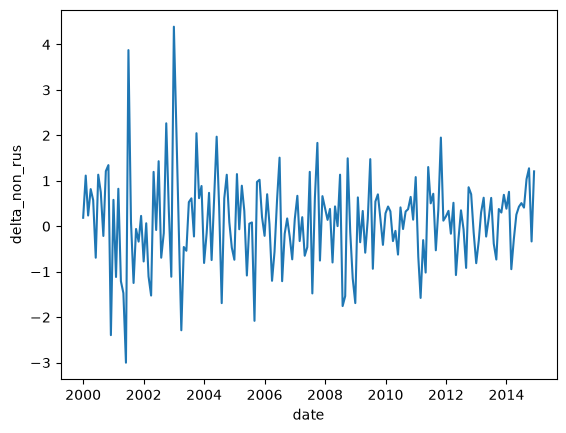

In [98]:
import seaborn as sns
sns.lineplot(x=world_oil_prod['date'], y=world_oil_prod['delta_non_rus'])

Видна стационарность переменной, следовательно можем использовать как переменную в модели, но все же проверим ее через ADF тест позже

## 3. Real Global Economic Activity Index (`rea_t`)

Цитата из статьи: The global real economic activity proxy is the index of real
economic activity (`rea_t`) constructed by Kilian (2009)

Он уже готовый, просто загружаем и используем

In [51]:
rea_t = pd.read_csv("../original_data/processed/igrea.csv")
ret_t['date'] = pd.to_datetime(rea_t['date'])

In [53]:
rea_t = (
    rea_t.loc[rea_t["date"].between("2000-01-01", "2014-12-01")]
    .copy()
    .reset_index(drop=True)
)
rea_t["date"].min(), rea_t["date"].max(), len(rea_t)

('2000-01-01', '2014-12-01', 180)

<Axes: xlabel='date', ylabel='rea_t'>

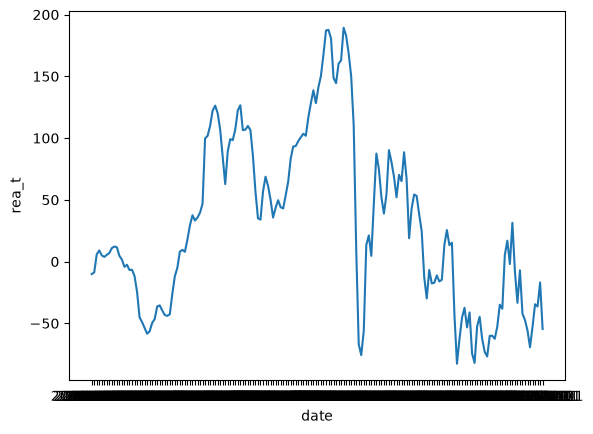

In [54]:
import seaborn as sns
sns.lineplot(x=rea_t['date'], y=rea_t['rea_t'])

## 4. rpo

Цитата из статьи: The real price of oil `rpo_t` is U.S. refiner acquisition cost of imported crude oil, from the U.S. Department of Energy deflated by the U.S. CPI

Значит берем ряд nominal_oil_price и дефлируем на ИПЦ

In [59]:
nominal_oil = pd.read_csv("../russian_data/processed/nominal_oil_price.csv")
nominal_oil['date'] = pd.to_datetime(nominal_oil['date'])

In [60]:
cpi_us = pd.read_csv("../original_data/processed/cpi_us.csv")
cpi_us['date'] = pd.to_datetime(cpi_us['date'])

In [61]:
df_oil_cpi = pd.merge(nominal_oil, cpi_us, on='date', how='inner')

In [62]:
df_oil_cpi['rpo'] = np.log(df_oil_cpi['npo_t'] / (df_oil_cpi['cpi_us'] / 100))
df_rpo = df_oil_cpi[['date', 'rpo']]

In [64]:
df_rpo = (
    df_rpo.loc[df_rpo["date"].between("2000-01-01", "2014-12-01")]
    .copy()
    .reset_index(drop=True)
)
df_rpo["date"].min(), df_rpo["date"].max(), len(df_rpo)

(Timestamp('2000-01-01 00:00:00'), Timestamp('2014-12-01 00:00:00'), 180)

<Axes: xlabel='date', ylabel='rpo'>

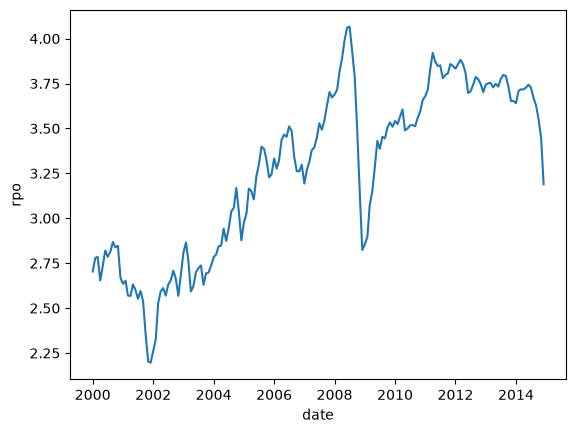

In [65]:
import seaborn as sns
sns.lineplot(x=df_rpo['date'], y=df_rpo['rpo'])

# Часть 3: мержим данные

In [99]:
df = df_rpo['date'].to_frame().copy()
pd.infer_freq(df['date'])

'MS'

In [104]:
df["date"].min(), df["date"].max(), len(df)

(Timestamp('2000-01-01 00:00:00'), Timestamp('2014-12-01 00:00:00'), 180)

In [101]:
df = pd.merge(df, ret_t, on='date', how='left')

In [103]:
df = pd.merge(df, df_rpo, on='date', how='left')

In [105]:
df = pd.merge(df, rea_t, on='date', how='left')

In [106]:
df = pd.merge(df, world_oil_prod[['date', 'delta_world', 'delta_non_rus']], on='date', how='left')

In [107]:
df

,date,ret_t,rpo,rea_t,delta_world,delta_non_rus
0,2000-01-01,20.508306,2.703907,-10.113044,0.274989,0.187119
1,2000-02-01,-0.895221,2.779550,-8.766956,1.106906,1.115102
2,2000-03-01,27.505884,2.784939,5.909950,0.274396,0.236799
3,2000-04-01,-5.413489,2.654156,8.995164,0.765926,0.817340
4,2000-05-01,-12.123873,2.733806,5.009274,0.599138,0.575270
...,...,...,...,...,...,...
175,2014-08-01,1.029960,3.670241,-52.811092,0.425677,0.410585
176,2014-09-01,0.493853,3.627996,-34.578872,0.933678,1.036886
177,2014-10-01,4.697298,3.551121,-36.350448,1.234880,1.275204
178,2014-11-01,2.173902,3.445831,-16.933751,-0.295374,-0.334066


In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           180 non-null    datetime64[us]
 1   ret_t          180 non-null    float64       
 2   rpo            180 non-null    float64       
 3   rea_t          180 non-null    float64       
 4   delta_world    180 non-null    float64       
 5   delta_non_rus  180 non-null    float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 8.6 KB


In [110]:
df.to_excel("../russian_data/processed/DATASET.xlsx", index=False)